# ED Alignment Algorithm on Real Piano Performances

This notebook evaluates the ED alignment algorithm in `compareMusic` on real piano performances from the [(n)ASAP: the (note-)Aligned Scores And Performances dataset](https://github.com/CPJKU/asap-dataset) (Peter et al., 2023).

(n)ASAP is a dataset of aligned musical scores and performances built by extending the ASAP dataset with note-level annotations. The ASAP contains 236 distinct musical scores and 1067 performances of Western classical piano music from 15 different composers, the piece directory contains the XML and MIDI score, plus all of the performances of a specific piece, including: 
- `midi_score`: the MIDI score (what should be played) — used as **reference**
- `midi_performance`: what the pianist actually played — used as **response**
- `note_alignments.tsv`: official note-level alignment annotations — used as **ground truth**

bib citation:

@article{Peter-2023,
 title = {Automatic Note-Level Score-to-Performance Alignments in the ASAP Dataset},
 author = {Peter, Silvan David and Cancino-Chacón, Carlos Eduardo and Foscarin, Francesco and McLeod, Andrew Philip and Henkel, Florian and Karystinaios, Emmanouil and Widmer, Gerhard},
 doi = {10.5334/tismir.149},
 journal = {Transactions of the International Society for Music Information Retrieval {(TISMIR)}},
 year = {2023}
}

relevant paper: https://transactions.ismir.net/articles/10.5334/tismir.149#5-alignment-of-the-asap-dataset

## Download the (n)ASAP Dataset

In [20]:
import os

# Note: use CPJKU version (not fosfrancesco) because only CPJKU has
# the note_alignments TSV files are needed for ground truth comparison.
if not os.path.exists("asap-dataset"):
    os.system("git clone https://github.com/CPJKU/asap-dataset.git")
else:
    print("asap-dataset already exists, skipping download.")

ASAP_PATH = "asap-dataset"

asap-dataset already exists, skipping download.


## Load the Ground Truth (GT)

The `note_alignment.tsv` file in each performance contains the official note-level alignment annotations. Each row represents one note, with columns: `xml_id`, `midi_id`, `track`, `channel`, `pitch`, `onset`.
- If `midi_id == "deletion"`: the score note was not played → label `deletion`
- If `xml_id == "insertion"`: an extra note was played → label `insertion`
- Otherwise: a matched pair → label `paired`

For `match` and `insertion` rows, the TSV provides `onset` (onset time in seconds) and `pitch` (MIDI pitch) for the performance note.

In [21]:
import csv

def load_ground_truth(tsv_path):
    """
    Read a note_alignments TSV file from the CPJKU ASAP dataset.

    Args:
        tsv_path: str, path to the note_alignments.tsv file

    Returns:
        list of dicts, each with keys:
            label  -> 'paired', 'insertion', or 'deletion'
            onset  -> float (seconds) or None for deletions
            pitch  -> int (MIDI pitch number) or None for deletions
    """
    rows = []
    with open(tsv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter="\t")
        
        for row in reader:
            xml_id  = row["xml_id"].strip()
            midi_id = row["midi_id"].strip()

            if midi_id == "deletion":
                rows.append({"label": "deletion", "onset": None, "pitch": None})
            elif xml_id == "insertion":
                rows.append({
                    "label": "insertion",
                    "onset": float(row["onset"]),
                    "pitch": int(row["pitch"]),
                })
            else:
                rows.append({
                    "label": "paired",
                    "onset": float(row["onset"]),
                    "pitch": int(row["pitch"]),
                })
    return rows

## Load Score (reference)/Performance (response) pairs

Helper functions for format conversion: These functions convert a MIDI file into the `{pitch, start, duration}` format used by `compare_MIDI.py`.

In [22]:
import pretty_midi

def midi_file_to_notes(midi_path):
    """
    Parse a MIDI file and return all its notes in compareMusic format.
    
    Args:
        midi_path: str, path to the MIDI file

    Returns:
        list of dicts sorted by onset time, each with keys:
            pitch -> int, MIDI note number
            start -> float, onset time in seconds
            duration -> float, note length in seconds
    """
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    all_notes = []
    for instrument in midi_data.instruments:
        if instrument.is_drum: # Ignore drum tracks
            continue
        for note in instrument.notes:
            all_notes.append({
                "pitch": note.pitch,
                "start": round(note.start, 3),
                "duration": round(note.end - note.start, 3),
            })
    # Sort by onset time, then by pitch (ensures consistent ordering for chords)
    all_notes.sort(key=lambda n: (n["start"], n["pitch"]))
    return all_notes


def build_sample(ref_path, response_path, composer, title, metadata_row):
    """
    Convert one score/performance MIDI pair into a sample dict
    ready for compare_performance_ED.

    Args:
        ref_path: str, path to the score (reference) MIDI file
        response_path: str, path to the performance (response) MIDI file
        composer: str
        title: str
        metadata_row: dict, one row from metadata.csv

    Returns:
        sample dict with keys: composer, title, reference, response, metadata_row
        Returns None if either MIDI file produces zero notes.
    """
    score_notes = midi_file_to_notes(ref_path)
    perf_notes  = midi_file_to_notes(response_path)

    # If either MIDI file has no notes, return None to indicate that this sample
    # should be skipped (e.g., some ASAP pieces have empty score or performance).
    if not score_notes or not perf_notes:
        return None

    return {
        "composer": composer,
        "title": title,
        "reference": {"notes": score_notes},
        "response": {"notes": perf_notes},
        "metadata_row": metadata_row,
    }

For the (n)ASAP dataset, the `metadata.csv` lists every score/performance pair in the dataset, check that both MIDI files exist on disk.

In [23]:
def load_samples(asap_path, composer=None, max_notes=8000):
    """
    Read the ASAP metadata CSV and return a list of sample dicts
    for a specific composer only.

    Args:
        asap_path:  str, path to the cloned ASAP repo root
        composer:   str or None.
                    If a string (e.g. "Bach"), only that composer is loaded.
                    If None, all composers in the dataset are loaded.
        max_notes:  int, skip any pair where either the score or performance
                    has more than this many notes. Default 3000.
                    Set to None to disable the limit.

    Returns:
        list of sample dicts (see build_sample)
    """
    metadata_path = os.path.join(asap_path, "metadata.csv")
    samples = []
    skipped = 0

    with open(metadata_path, "r", encoding="utf-8") as csv_file:
        reader = csv.DictReader(csv_file)

        for row in reader:
            row_composer = row.get("composer", "").strip()
            # Skip rows that do not match the requested composer (if one is given)
            if composer is not None and row_composer != composer:
                continue

            ref_path = os.path.join(asap_path, row.get("midi_score", "").strip())
            response_path = os.path.join(asap_path, row.get("midi_performance", "").strip())

            if os.path.isfile(ref_path) and os.path.isfile(response_path):
                sample = build_sample(
                    ref_path, response_path,
                    row_composer,     
                    row.get("title", "Unknown"),
                    dict(row),
                    )

                if sample is not None:
                    ref_count  = len(sample["reference"]["notes"])
                    perf_count = len(sample["response"]["notes"])
                    exceeds_limit = (
                        max_notes is not None
                        and (ref_count > max_notes or perf_count > max_notes)
                    )
                    if exceeds_limit:                            
                        skipped = skipped + 1
                    else:
                        samples.append(sample)

    print(f"Skipped {skipped} pairs due to exceeding max_notes limit of {max_notes}")
    print(f"Loaded {len(samples)} score (reference) / performance (response) pairs.")
    return samples

samples = load_samples(ASAP_PATH, composer=None, max_notes=8000)

/Users/jz7125/compareMusic/.venv/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Skipped 45 pairs due to exceeding max_notes limit of 8000
Loaded 1021 score (reference) / performance (response) pairs.


# Run Alignment on Each Pair

Passing each score/performance pair through `compare_performance_ED`, where score MIDI is the reference and the performance MIDI is the response.

**Why do we need the normalised events? - to fix the onset mismatch bug**
- Inside `compare_performance_ED`, `normalize_start_times` shifts the first note to t = 0, and `group_notes_into_events` groups simultaneous notes into chords. The `response_index` values stored in `event_details` refer to positions in these grouped events, not in the original flat note list. Therefore, need to reproduce these two steps here so that the correct onset and pitch for each event during ground truth comparison can be looked up.
- The `response_onset_offset` (the original first-note onset before normalisation) will also be recorded, and will be added back when comparing normalised pipeline onsets against the original (absolute) times stored in the ground truth TSV.

In [24]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

from asap_worker import evaluate_one_sample


def run_alignment_on_samples_parallel(samples, max_workers=None):
    """
    Run evaluate_one_sample on every sample using a process pool, so multiple
    pieces are aligned at the same time on different CPU cores.

    Args:
        samples: list of sample dicts from load_samples()
        max_workers: int or None. None means "all CPU cores minus one",
                     leaving one core free for the OS and other apps.

    Returns:
        results: list of successful result dicts
        failed: list of (composer, title, error_message) for pieces that failed
    """
    if max_workers is None:
        max_workers = max(1, os.cpu_count() - 1)

    results = []
    failed = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        future_to_sample = {
            executor.submit(evaluate_one_sample, sample): sample
            for sample in samples
        }

        for future in tqdm(as_completed(future_to_sample), total=len(samples)):
            sample = future_to_sample[future]
            result = future.result()  # exceptions are already caught inside the worker

            if result["error"] is not None:
                failed.append((result["composer"], result["title"], result["error"]))
            else:
                results.append(result)

    print("Succeeded:", len(results), " Failed:", len(failed))
    return results, failed


all_results, failed_pieces = run_alignment_on_samples_parallel(samples)

100%|██████████| 1021/1021 [09:20<00:00,  1.82it/s]

Succeeded: 1021  Failed: 0


## Compute Precision, Recall, and F1 

**our pipeline vs GT**

The GT has three different labels, while our pipeline has four operations:

| Pipeline operation | GT label | Explanation |
|---|---|---|
| `match` | `paired` | Same pitch — GT still calls this `paired` |
| `replacement` | `paired` | Different pitch — GT still calls this `paired`, because the score note *was* played at approximately the right time |
| `missing` | `deletion` | Score note not found in response |
| `extra` | `insertion` | Response note has no score counterpart |

**Evaluation metrics design**

GT does not distinguish `match` from `replacement` because the alignment methods in GT are based on the temporal information. However, the cost function in our edit distance algorithm is based on the pitch correctness. 

Following Peter et al. (2023, TISMIR), label-level F1 would be applied as the main metric where TP, FP, and FN are computed separately for each label type and then summed:

| Label | Matching key | TP | FP | FN |
|---|---|---|---|---|
| `paired` (pipeline `match` / `replacement`) | onset only (rounded to 1 d.p.) | Pipeline and ground truth agree a score note was aligned to a performance note at this onset (regardless of pitch correctness) | Pipeline predicts a pairing at this onset that the ground truth does not recognise | Ground truth expects a pairing at this onset that the pipeline fails to find |
| `deletion` (pipeline `missing`) | count only as no onset or pitch available for deletions | Overlap between the number of notes the pipeline judges as missing and the number the ground truth judges as missing | Pipeline predicts more missing notes than the ground truth; the excess | Ground truth expects more missing notes than the pipeline predicts; the shortfall |
| `insertion` (pipeline `extra`) | `(pitch, onset)` | Pipeline and ground truth agree an extra, unexpected note was played at this pitch and onset | Pipeline flags a note as extra that the ground truth does not agree with | Ground truth marks a note as extra that the pipeline fails to identify |

- Precision: TP / (TP + FP), i.e. of all labels the pipeline predicted, how many were correct  
- Recall: TP / (TP + FN), i.e. of all GT labels, how many the pipeline found  
- F1: the harmonic mean of precision and recall 

In [25]:
def convert_pipeline_output(event_details, response_events_normalized, ref_events_normalized):
    """
    Convert event_details from compare_performance_ED into a list of
    dicts with keys: onset, pitch, label.

    Note: for aligned (match/replacement) chord pairs, correct_pitches /
    missing_pitches / extra_pitches inside event_details are now already
    real MIDI pitch multisets (with octave, computed by compute_chord_accuracy
    in compare_MIDI.py), so they are reused directly here instead of being
    re-derived. response_events_normalized / ref_events_normalized are still
    needed for onset lookups, and for the full note list of entirely-missing
    or entirely-extra chords (event_details only stores the chord name, not
    individual pitches, in those two cases).

    Args:
        event_details: list of dicts from compare_performance_ED
        response_events_normalized: list of event dicts (real notes, grouped)
        ref_events_normalized: list of event dicts (real notes, grouped)

    Returns:
        list of dicts with keys: onset, pitch, label
    """
    my_pairs = []

    for event in event_details:
        op = event["operation_type"]

        if event["event_type"] == "note":
            if op in ("match", "replacement"):
                ev = response_events_normalized[event["response_index"] - 1]
                my_pairs.append({
                    "onset": ev["event_start"],
                    "pitch": ev["notes"][0]["pitch"],
                    "label": "paired",
                })
            elif op == "missing":
                my_pairs.append({"onset": None, "pitch": None, "label": "deletion"})
            elif op == "extra":
                ev = response_events_normalized[event["response_index"] - 1]
                my_pairs.append({
                    "onset": ev["event_start"],
                    "pitch": ev["notes"][0]["pitch"],
                    "label": "insertion",
                })

        elif event["event_type"] == "chord":
            if op == "missing":
                # Whole chord missing -- event_details only has the chord name,
                # so the individual reference pitches still need to be looked up.
                ref_ev = ref_events_normalized[event["reference_index"] - 1]
                for note in ref_ev["notes"]:
                    my_pairs.append({"onset": None, "pitch": None, "label": "deletion"})

            elif op == "extra":
                # Whole chord extra -- same reasoning, look up response pitches.
                res_ev = response_events_normalized[event["response_index"] - 1]
                for note in res_ev["notes"]:
                    my_pairs.append({
                        "onset": res_ev["event_start"],
                        "pitch": note["pitch"],
                        "label": "insertion",
                    })

            else:
                # Aligned chord pair (match or replacement). compare_MIDI.py's
                # compute_chord_accuracy already computed correct/missing/extra
                # pitches as real MIDI pitch multisets, so reuse them directly
                # instead of re-deriving with a Counter here.
                res_ev = response_events_normalized[event["response_index"] - 1]
                onset = res_ev["event_start"]

                for pitch in event["correct_pitches"]:
                    my_pairs.append({"onset": onset, "pitch": pitch, "label": "paired"})

                for pitch in event["missing_pitches"]:
                    my_pairs.append({"onset": None, "pitch": None, "label": "deletion"})

                for pitch in event["extra_pitches"]:
                    my_pairs.append({"onset": onset, "pitch": pitch, "label": "insertion"})

    return my_pairs

In [26]:
from collections import Counter

def count_paired_matches(ground_truth, my_pairs, onset_offset):
    """
    Count TP, FP, FN for 'paired' labels.
    Matching key: (pitch, onset rounded to 1 d.p.) -- pitch is now
    included, and Counter (multiset) is used instead of set, so that
    multiple notes sharing the same onset (chords) are no longer
    collapsed into a single entry.
    """
    gt_counter = Counter()
    for row in ground_truth:
        if row["label"] == "paired":
            key = (int(row["pitch"]), round(float(row["onset"]), 1))
            gt_counter[key] = gt_counter[key] + 1

    my_counter = Counter()
    for row in my_pairs:
        if row["label"] == "paired" and row["onset"] is not None:
            absolute_onset = row["onset"] + onset_offset
            key = (int(row["pitch"]), round(float(absolute_onset), 1))
            my_counter[key] = my_counter[key] + 1

    tp = 0
    for key in gt_counter:
        tp += min(gt_counter[key], my_counter[key])
    fp = sum((my_counter - gt_counter).values())
    fn = sum((gt_counter - my_counter).values())
    return tp, fp, fn


def count_deletion_matches(ground_truth, my_pairs):
    """
    Count TP, FP, FN for 'deletion' labels.

    Deletions have no onset or pitch (the note was never played), so
    identity-based matching is not possible. Count-based matching is used:
        TP = min(GT deletion count, predicted deletion count)
        FP = max(0, predicted count - GT count)
        FN = max(0, GT count - predicted count)

    Args:
        ground_truth: list of dicts from load_ground_truth()
        my_pairs: list of dicts from convert_pipeline_output()

    Returns:
        tp, fp, fn: ints
    """
    gt_deletion_count = sum(1 for row in ground_truth if row["label"] == "deletion")
    my_deletion_count = sum(1 for row in my_pairs if row["label"] == "deletion")

    tp = min(gt_deletion_count, my_deletion_count)
    fp = max(0, my_deletion_count - gt_deletion_count)
    fn = max(0, gt_deletion_count - my_deletion_count)

    return tp, fp, fn


def count_insertion_matches(ground_truth, my_pairs, onset_offset):
    """
    Count TP, FP, FN for 'insertion' labels.
    Same multiset fix as count_paired_matches.
    """
    gt_counter = Counter()
    for row in ground_truth:
        if row["label"] == "insertion":
            key = (int(row["pitch"]), round(float(row["onset"]), 1))
            gt_counter[key] = gt_counter[key] + 1

    my_counter = Counter()
    for row in my_pairs:
        if row["label"] == "insertion" and row["onset"] is not None:
            absolute_onset = row["onset"] + onset_offset
            key = (int(row["pitch"]), round(float(absolute_onset), 1))
            my_counter[key] = my_counter[key] + 1

    tp = 0
    for key in gt_counter:
        tp += min(gt_counter[key], my_counter[key])
    fp = sum((my_counter - gt_counter).values())
    fn = sum((gt_counter - my_counter).values())
    return tp, fp, fn

In [27]:
def compute_metrics_label_level(ground_truth, my_pairs, onset_offset=0.0):
    """
    Compute label-level precision, recall, and F1 following Peter et al. (2023).
    Args:
        ground_truth: list of dicts from load_ground_truth()
        my_pairs: list of dicts from convert_pipeline_output()
        onset_offset: float, the first-note onset before normalisation.
                      Added back to convert normalised onsets to absolute time.

    Returns:
        dict with keys:
            precision, recall, f1 -> floats (rounded to 4 d.p.)
            tp, fp, fn  -> ints (totals across all labels)
            tp_paired, fp_paired, fn_paired
            tp_deletion, fp_deletion, fn_deletion
            tp_insertion, fp_insertion, fn_insertion
    """
    # Count TP/FP/FN separately for each label type
    tp_p, fp_p, fn_p = count_paired_matches(ground_truth, my_pairs, onset_offset)
    tp_d, fp_d, fn_d = count_deletion_matches(ground_truth, my_pairs)
    tp_i, fp_i, fn_i = count_insertion_matches(ground_truth, my_pairs, onset_offset)

    # Sum across all label types for overall metrics
    tp = tp_p + tp_d + tp_i
    fp = fp_p + fp_d + fp_i
    fn = fn_p + fn_d + fn_i

    # Precision: of all labels predicted, how many are correct
    if tp + fp > 0:
        precision = tp / (tp + fp)
    else:
        precision = 0.0

    # Recall: of all GT labels, how many the pipeline found
    if tp + fn > 0:
        recall = tp / (tp + fn)
    else:
        recall = 0.0

    # F1: harmonic mean of precision and recall
    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0.0

    return {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "tp": tp, "fp": fp, "fn": fn,
        # Per-label breakdown -- useful for diagnosing which label type is weakest
        "tp_paired": tp_p, "fp_paired": fp_p, "fn_paired": fn_p,
        "tp_deletion": tp_d, "fp_deletion": fp_d, "fn_deletion": fn_d,
        "tp_insertion": tp_i, "fp_insertion": fp_i, "fn_insertion": fn_i,
    }

Evaluate against ground truth:

In [28]:
def evaluate_one_piece(asap_path, metadata_row, event_details,
                       response_events_normalized, ref_events_normalized,
                       response_onset_offset):
    """
    Run ground truth comparison for each score/performance pair.

    Args:
        asap_path: str, path to ASAP repo root
        metadata_row: dict, one row from metadata.csv
        event_details: list from compare_performance_ED result
        response_events_normalized: list of event dicts (normalized + grouped)
        response_onset_offset: float, onset of the first response note
                               before normalization — added back to convert
                               normalised onsets to absolute times for GT comparison.

    Returns:
        metrics dict, or None if the TSV file is not found
    """
    tsv_rel = metadata_row.get("note_alignments", "").strip()
    tsv_path = os.path.join(asap_path, tsv_rel)

    if not os.path.isfile(tsv_path):
        return None

    ground_truth = load_ground_truth(tsv_path)
    my_pairs = convert_pipeline_output(
        event_details, response_events_normalized, ref_events_normalized
    )
    metrics = compute_metrics_label_level(ground_truth, my_pairs, onset_offset=response_onset_offset)

    return metrics

In [29]:
import pandas as pd

eval_rows = []
skipped_count = 0

for result in all_results:
    metrics = evaluate_one_piece(
        ASAP_PATH,
        result["metadata_row"],
        result["event_details"],
        result["response_events_normalized"],
        result["ref_events_normalized"],       
        result["response_onset_offset"],
    )
    if metrics is not None:
        eval_rows.append({
            "Piece": result["composer"] + " (" + result["title"] + ")",
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1": metrics["f1"],
            "TP": metrics["tp"],
            "FP": metrics["fp"],
            "FN": metrics["fn"],
        })
    else:
        skipped_count += 1

print(f"Skipped {skipped_count} piece(s) due to missing TSV file.")

df_eval = pd.DataFrame(eval_rows)
display(df_eval.head(10))

print("Mean Precision:", round(df_eval["Precision"].mean(), 4))
print("Mean Recall :", round(df_eval["Recall"].mean(), 4))
print("Mean F1 :", round(df_eval["F1"].mean(), 4))

Skipped 30 piece(s) due to missing TSV file.


,Piece,Precision,Recall,F1,TP,FP,FN
0,Bach (Fugue_bwv_846),0.9091,0.9257,0.9173,710,71,57
1,Bach (Fugue_bwv_848),0.9274,0.9281,0.9278,1355,106,105
2,Bach (Fugue_bwv_848),0.9440,0.9414,0.9427,1365,81,85
3,Bach (Fugue_bwv_848),0.9544,0.9511,0.9527,1380,66,71
4,Bach (Fugue_bwv_848),0.9336,0.9374,0.9355,1363,97,91
5,Bach (Fugue_bwv_848),0.9580,0.9553,0.9566,1390,61,65
6,Bach (Fugue_bwv_848),0.9533,0.9520,0.9526,1388,68,70
7,Bach (Fugue_bwv_848),0.9204,0.9260,0.9232,1352,117,108
8,Bach (Fugue_bwv_848),0.9203,0.9291,0.9246,1362,118,104
9,Bach (Fugue_bwv_854),0.9367,0.9379,0.9373,695,47,46


Mean Precision: 0.8391
Mean Recall : 0.8628
Mean F1 : 0.8502


In [30]:
eval_rows_detailed = []

for result in all_results:
    metrics = evaluate_one_piece(
        ASAP_PATH,
        result["metadata_row"],
        result["event_details"],
        result["response_events_normalized"],
        result["ref_events_normalized"],
        result["response_onset_offset"],
    )
    if metrics is not None:
        eval_rows_detailed.append({
            "Composer": result["composer"],
            "Title": result["title"],
            "Performance": result["metadata_row"].get("midi_performance", ""),
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1": metrics["f1"],
            "TP": metrics["tp"],
            "FP": metrics["fp"],
            "FN": metrics["fn"],
            "metrics": metrics,   # full dict, includes per-label (paired/deletion/insertion) breakdown
            "result": result,     # full result dict, for event-level drill-down later
        })

df_detailed = pd.DataFrame(eval_rows_detailed)

# Sort by F1 ascending -- worst performances first
worst_n = 10
df_worst = df_detailed.sort_values("F1").head(worst_n)
display(df_worst[["Composer", "Title", "Performance", "Precision", "Recall", "F1", "TP", "FP", "FN"]])

,Composer,Title,Performance,Precision,Recall,F1,TP,FP,FN
666,Chopin,Scherzos_20,Chopin/Scherzos/20/Wong04M.mid,0.3195,0.1892,0.2377,1606,3420,6882
983,Scriabin,Sonatas_5,Scriabin/Sonatas/5/ChernovA06M.mid,0.3917,0.2573,0.3106,3548,5509,10241
442,Chopin,Ballades_1,Chopin/Ballades/1/MunA19M.mid,0.4603,0.3122,0.3721,2591,3038,5708
382,Beethoven,Piano_Sonatas_31-3_4,Beethoven/Piano_Sonatas/31-3_4/HuangSW10M.mid,0.5562,0.4399,0.4913,2307,1841,2937
692,Chopin,Sonata_2_3rd,Chopin/Sonata_2/3rd_extra_repeat/KaszoS15.mid,0.4391,0.5860,0.5021,1465,1871,1035
984,Scriabin,Sonatas_5,Scriabin/Sonatas/5/Ko07M.mid,0.5720,0.4490,0.5031,5588,4182,6857
932,Schubert,Impromptu_op142_3,Schubert/Impromptu_op142/3/SunY08M.mid,0.5796,0.4831,0.5270,4123,2990,4411
340,Beethoven,Piano_Sonatas_3-1,Beethoven/Piano_Sonatas/3-1/LUO01.mid,0.6166,0.4715,0.5344,2964,1843,3322
985,Scriabin,Sonatas_5,Scriabin/Sonatas/5/FALIKS06.mid,0.6252,0.5111,0.5624,5756,3451,5505
604,Chopin,Etudes_op_25_1,Chopin/Etudes_op_25/1/TongB02M.mid,0.5111,0.6564,0.5747,1471,1407,770


In [33]:
# Add ResultIndex so each row in df_eval can be traced back to all_results
eval_rows = []
skipped_count = 0

for idx, result in enumerate(all_results):
    metrics = evaluate_one_piece(
        ASAP_PATH,
        result["metadata_row"],
        result["event_details"],
        result["response_events_normalized"],
        result["ref_events_normalized"],
        result["response_onset_offset"],
    )
    if metrics is not None:
        eval_rows.append({
            "Piece": result["composer"] + " (" + result["title"] + ")",
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1": metrics["f1"],
            "TP": metrics["tp"], "FP": metrics["fp"], "FN": metrics["fn"],
            "ResultIndex": idx,   # NEW -- lets us fetch all_results[idx] later
        })
    else:
        skipped_count = skipped_count + 1

df_eval = pd.DataFrame(eval_rows)
print(f"Skipped {skipped_count} piece(s) due to missing TSV file.")

Skipped 30 piece(s) due to missing TSV file.


In [34]:
N_WORST = 5
worst_df = df_eval.sort_values("F1").head(N_WORST)
worst_df

,Piece,Precision,Recall,F1,TP,FP,FN,ResultIndex
666,Chopin (Scherzos_20),0.3195,0.1892,0.2377,1606,3420,6882,667
983,Scriabin (Sonatas_5),0.3917,0.2573,0.3106,3548,5509,10241,1013
442,Chopin (Ballades_1),0.4603,0.3122,0.3721,2591,3038,5708,443
382,Beethoven (Piano_Sonatas_31-3_4),0.5562,0.4399,0.4913,2307,1841,2937,383
692,Chopin (Sonata_2_3rd),0.4391,0.5860,0.5021,1465,1871,1035,693


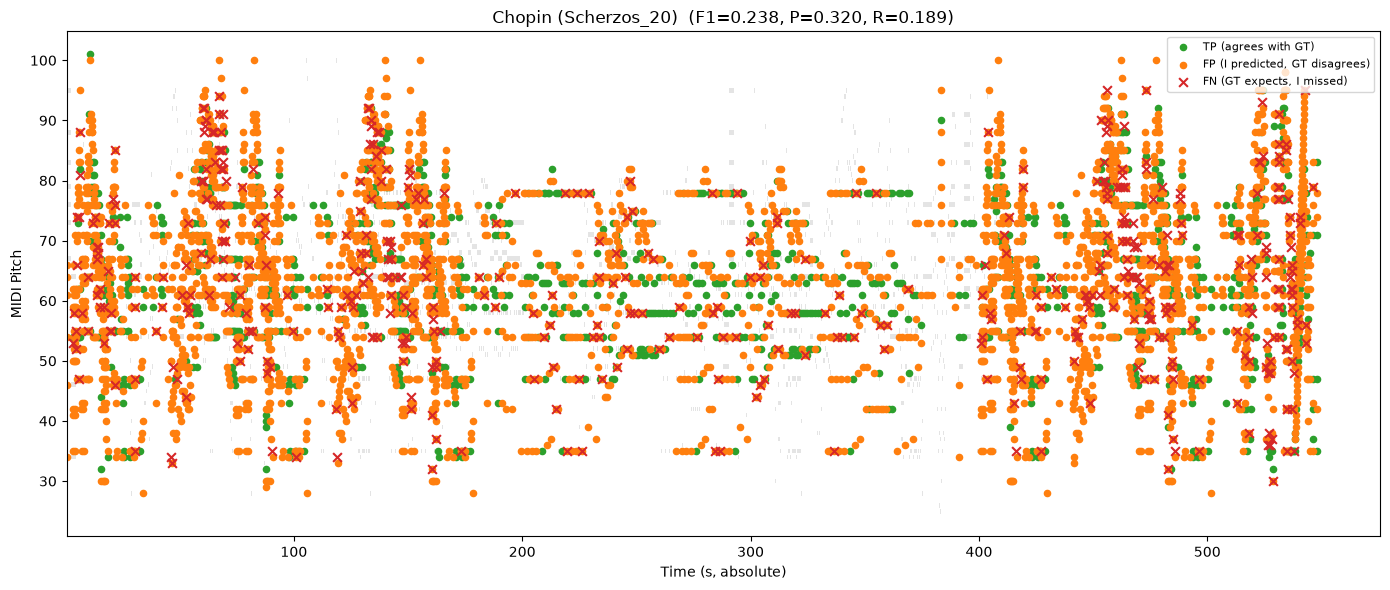

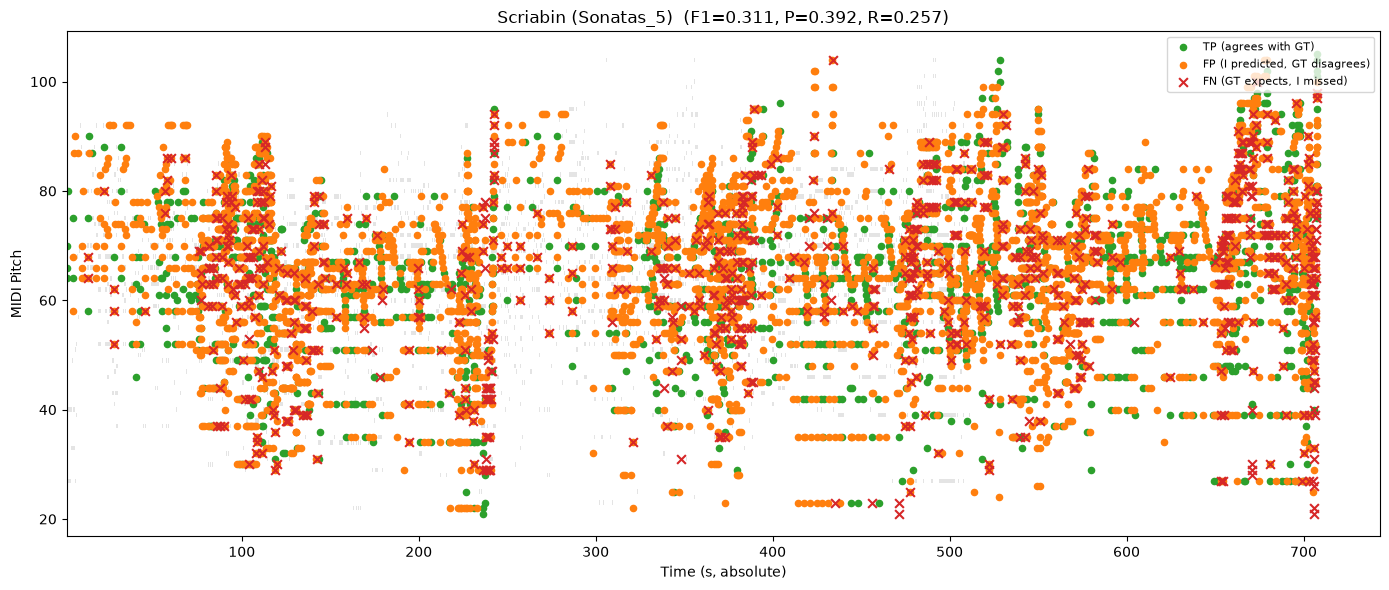

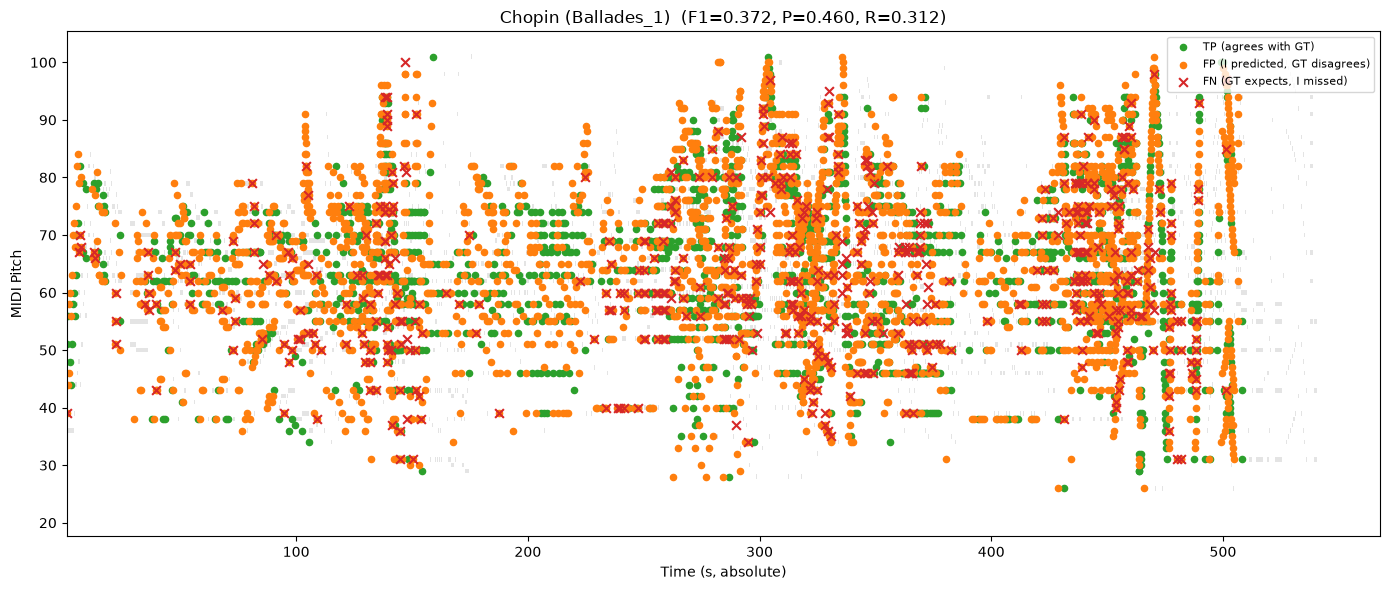

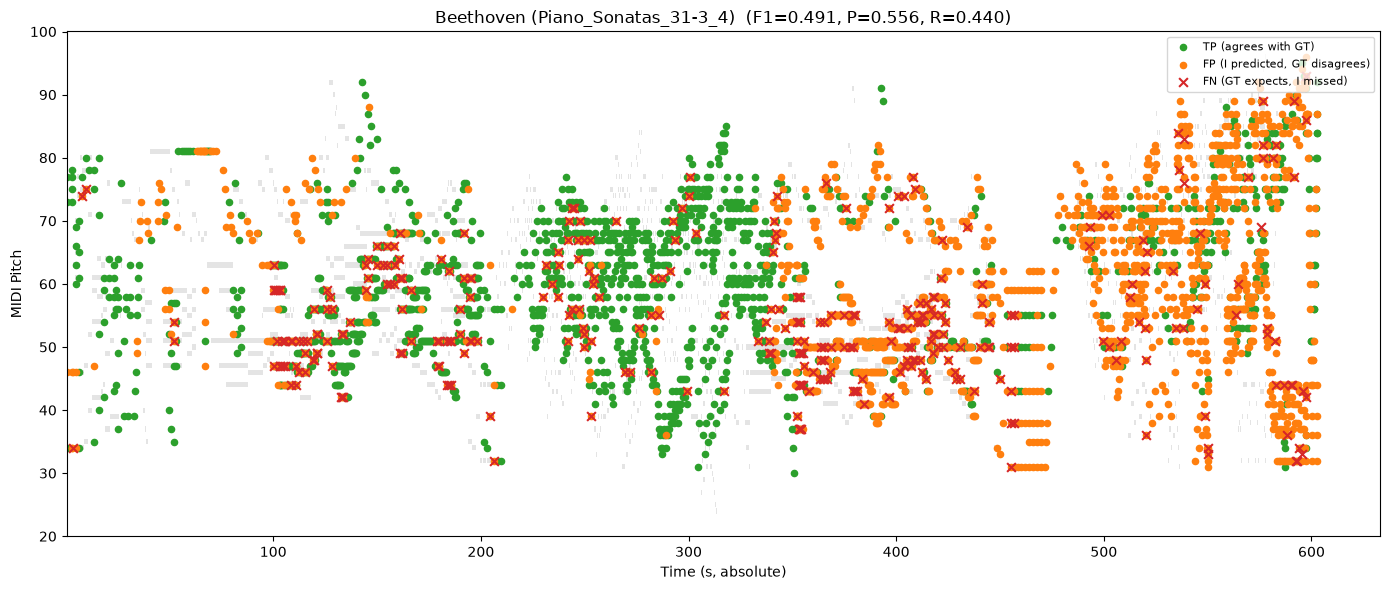

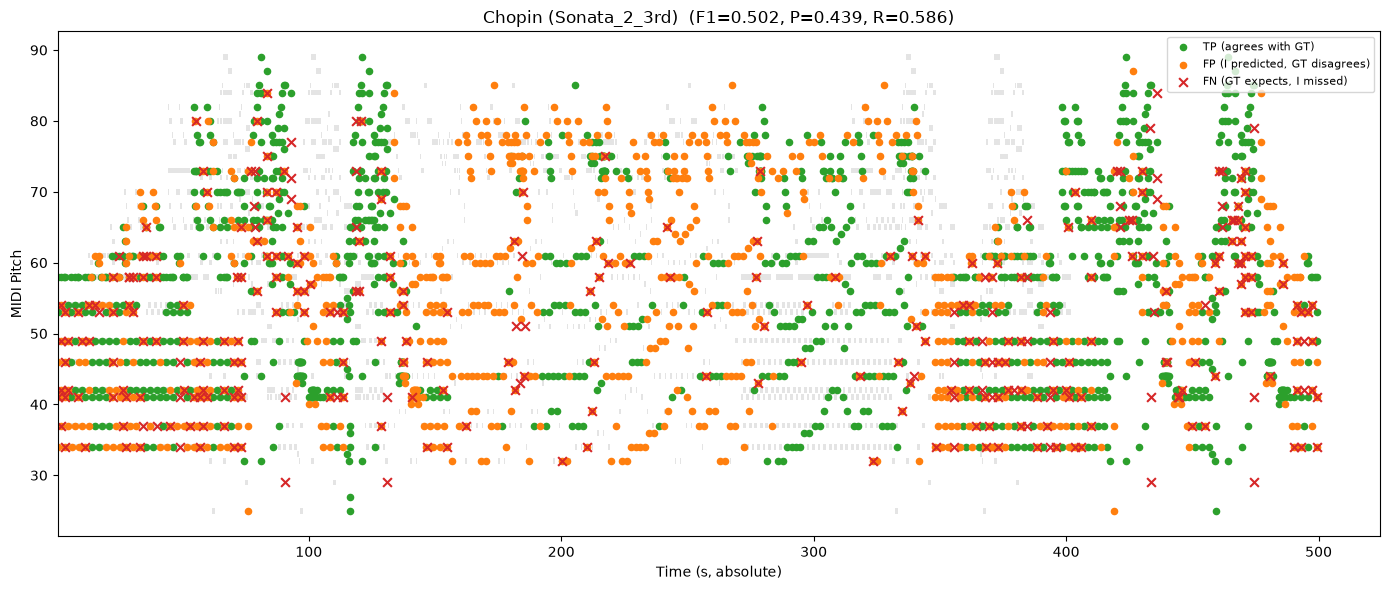

In [35]:
import matplotlib.pyplot as plt

for _, row in worst_df.iterrows():
    result = all_results[row["ResultIndex"]]
    onset_offset = result["response_onset_offset"]

    # ---- Reload ground truth and my_pairs for this piece ----
    tsv_path = os.path.join(ASAP_PATH, result["metadata_row"].get("note_alignments", "").strip())
    ground_truth = load_ground_truth(tsv_path)
    my_pairs = convert_pipeline_output(
        result["event_details"],
        result["response_events_normalized"],
        result["ref_events_normalized"],
    )

    # ---- Build GT lookup counters for tagging TP vs FP ----
    gt_paired = Counter(
        (int(r["pitch"]), round(float(r["onset"]), 1))
        for r in ground_truth if r["label"] == "paired"
    )
    gt_insertion = Counter(
        (int(r["pitch"]), round(float(r["onset"]), 1))
        for r in ground_truth if r["label"] == "insertion"
    )

    # ---- Tag each of my paired/insertion notes as TP or FP ----
    seen_paired = Counter()
    seen_insertion = Counter()
    tp_x, tp_y = [], []
    fp_x, fp_y = [], []

    for pair in my_pairs:
        if pair["onset"] is None:
            continue  # deletions have no note position to plot
        absolute_onset = pair["onset"] + onset_offset
        key = (int(pair["pitch"]), round(float(absolute_onset), 1))

        if pair["label"] == "paired":
            seen_paired[key] = seen_paired[key] + 1
            is_tp = seen_paired[key] <= gt_paired[key]
        else:
            seen_insertion[key] = seen_insertion[key] + 1
            is_tp = seen_insertion[key] <= gt_insertion[key]

        if is_tp:
            tp_x.append(absolute_onset); tp_y.append(pair["pitch"])
        else:
            fp_x.append(absolute_onset); fp_y.append(pair["pitch"])

    # ---- Find FN: GT paired/insertion notes my pipeline never produced ----
    my_paired_counter = Counter(
        (int(p["pitch"]), round(float(p["onset"] + onset_offset), 1))
        for p in my_pairs if p["label"] == "paired" and p["onset"] is not None
    )
    my_insertion_counter = Counter(
        (int(p["pitch"]), round(float(p["onset"] + onset_offset), 1))
        for p in my_pairs if p["label"] == "insertion" and p["onset"] is not None
    )
    fn_x, fn_y = [], []
    for r in ground_truth:
        if r["label"] in ("paired", "insertion") and r["onset"] is not None:
            key = (int(r["pitch"]), round(float(r["onset"]), 1))
            found = my_paired_counter[key] + my_insertion_counter[key]
            expected = gt_paired[key] + gt_insertion[key] if r["label"] == "paired" else gt_insertion[key]
            # crude check: if GT count for this key exceeds what I produced, it's an FN instance
            if found < (gt_paired[key] if r["label"] == "paired" else gt_insertion[key]):
                fn_x.append(r["onset"]); fn_y.append(r["pitch"])

    # ---- Plot: piano roll of reference vs response, overlaid with TP/FP/FN ----
    fig, ax = plt.subplots(figsize=(14, 6))

    for ev in result["ref_events_normalized"]:
        for note in ev["notes"]:
            ax.barh(note["pitch"], note["duration"], left=note["start"] + onset_offset,
                    height=0.8, color="lightgray", alpha=0.6)

    ax.scatter(tp_x, tp_y, color="tab:green", s=20, label="TP (agrees with GT)")
    ax.scatter(fp_x, fp_y, color="tab:orange", s=20, label="FP (I predicted, GT disagrees)")
    ax.scatter(fn_x, fn_y, color="tab:red", marker="x", s=40, label="FN (GT expects, I missed)")

    ax.set_title(row["Piece"] + f"  (F1={row['F1']:.3f}, P={row['Precision']:.3f}, R={row['Recall']:.3f})")
    ax.set_xlabel("Time (s, absolute)")
    ax.set_ylabel("MIDI Pitch")
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

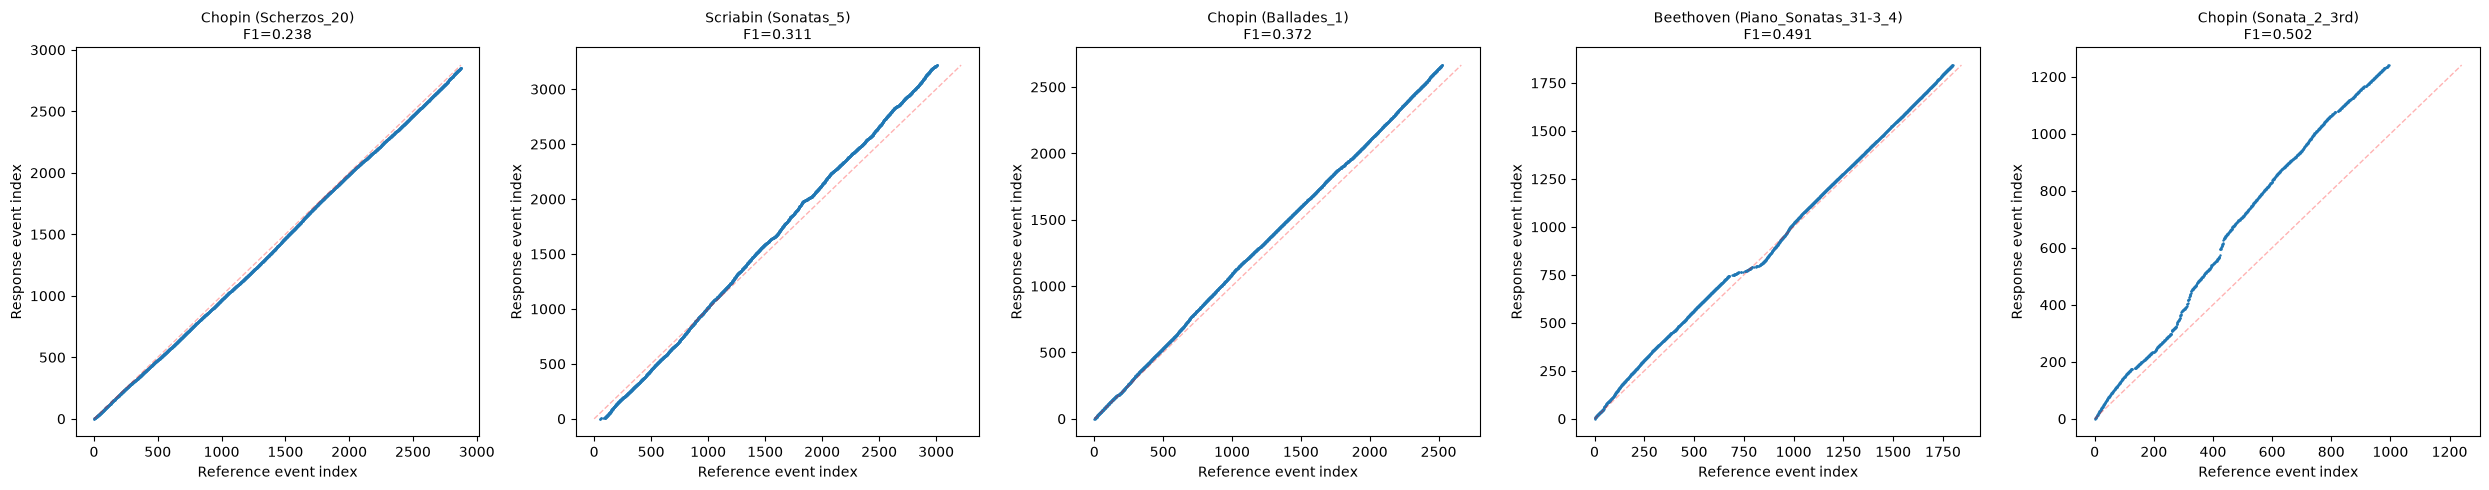

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(worst_df), figsize=(5 * len(worst_df), 5))

for ax, (_, row) in zip(axes, worst_df.iterrows()):
    result = all_results[row["ResultIndex"]]

    ref_idx_list = []
    res_idx_list = []
    for op in result["event_details"]:
        if op["reference_index"] is not None and op["response_index"] is not None:
            ref_idx_list.append(op["reference_index"])
            res_idx_list.append(op["response_index"])

    ax.plot(ref_idx_list, res_idx_list, ".", markersize=1.5)

    max_idx = max(max(ref_idx_list), max(res_idx_list))
    ax.plot([0, max_idx], [0, max_idx], "r--", alpha=0.3, linewidth=1)

    ax.set_title(row["Piece"] + f"\nF1={row['F1']:.3f}", fontsize=10)
    ax.set_xlabel("Reference event index")
    ax.set_ylabel("Response event index")

plt.tight_layout()
plt.show()

In [38]:
import numpy as np

# Beethoven Piano_Sonatas_31-3_4 has a very clean single step around ref index ~700-900
result = all_results[383]  # ResultIndex for Beethoven from worst_df

# Find the reference-index range where the alignment path deviates most
# from a straight line, so we zoom into the step itself.
ref_idx_list = []
res_idx_list = []
for op in result["event_details"]:
    if op["reference_index"] is not None and op["response_index"] is not None:
        ref_idx_list.append(op["reference_index"])
        res_idx_list.append(op["response_index"])

ref_arr = np.array(ref_idx_list)
res_arr = np.array(res_idx_list)

# Rough diagonal for comparison, scaled to the same total range
diagonal = ref_arr * (res_arr[-1] / ref_arr[-1])
deviation = res_arr - diagonal

# The reference index where response gets furthest ahead of "ideal" pace
step_center = ref_arr[np.argmax(deviation)]
print("Step is centered around reference index:", step_center)

# Zoom into a small window around that step and print the real notes
window = 15
ref_events = result["ref_events_normalized"]
res_events = result["response_events_normalized"]

print("\n--- Reference events around the step ---")
for i in range(max(0, step_center - window), min(len(ref_events), step_center + window)):
    ev = ref_events[i]
    pitches = [note["pitch"] for note in ev["notes"]]
    print(f"ref[{i}]  start={ev['event_start']:.3f}  type={ev['event_type']}  pitches={pitches}")

print("\n--- Response events around the same time ---")
ref_time = ref_events[step_center]["event_start"]
for ev in res_events:
    if abs(ev["event_start"] - ref_time) < 2.0:  # +/- 2 seconds window
        pitches = [note["pitch"] for note in ev["notes"]]
        print(f"start={ev['event_start']:.3f}  type={ev['event_type']}  pitches={pitches}")

Step is centered around reference index: 290

--- Reference events around the step ---
ref[275]  start=186.283  type=chord  pitches=[51, 55, 58, 61]
ref[276]  start=186.883  type=chord  pitches=[51, 55, 58, 61]
ref[277]  start=187.483  type=chord  pitches=[51, 55, 58, 61, 67]
ref[278]  start=188.083  type=chord  pitches=[52, 55, 58, 61, 70]
ref[279]  start=188.683  type=chord  pitches=[52, 55, 58, 61]
ref[280]  start=189.283  type=chord  pitches=[52, 55, 58, 61]
ref[281]  start=189.883  type=chord  pitches=[51, 55, 58, 61, 63]
ref[282]  start=190.483  type=chord  pitches=[51, 55, 58, 61, 63]
ref[283]  start=191.083  type=chord  pitches=[51, 55, 58, 61, 63]
ref[284]  start=191.683  type=chord  pitches=[56, 59, 63, 68]
ref[285]  start=193.483  type=chord  pitches=[35, 47, 59]
ref[286]  start=195.283  type=chord  pitches=[34, 46, 58]
ref[287]  start=197.083  type=chord  pitches=[39, 51, 63]
ref[288]  start=198.883  type=chord  pitches=[32, 44, 56]
ref[289]  start=200.683  type=chord  pitc

In [43]:
from collections import Counter

result = all_results[383]  # Beethoven, from worst_df

op_counts = Counter(ev["operation_type"] for ev in result["event_details"])
total = sum(op_counts.values())

print("Operation type breakdown for this piece:")
for op_type, count in op_counts.most_common():
    print(f"  {op_type}: {count}  ({100 * count / total:.1f}%)")

Operation type breakdown for this piece:
  match: 1494  (76.6%)
  replacement: 196  (10.0%)
  extra: 153  (7.8%)
  missing: 108  (5.5%)


In [44]:
window_start, window_end = 105.0, 132.0

print("--- Reference events in 105-132s ---")
for i, ev in enumerate(result["ref_events_normalized"]):
    if window_start <= ev["event_start"] <= window_end:
        pitches = [note["pitch"] for note in ev["notes"]]
        print(f"ref[{i}]  start={ev['event_start']:.3f}  type={ev['event_type']}  pitches={pitches}")

print("\n--- Response events in 105-132s ---")
for i, ev in enumerate(result["response_events_normalized"]):
    if window_start <= ev["event_start"] <= window_end:
        pitches = [note["pitch"] for note in ev["notes"]]
        print(f"res[{i}]  start={ev['event_start']:.3f}  type={ev['event_type']}  pitches={pitches}")

--- Reference events in 105-132s ---
ref[138]  start=105.133  type=note  pitches=[71]
ref[139]  start=105.283  type=chord  pitches=[51, 55, 58, 70]
ref[140]  start=105.883  type=chord  pitches=[51, 55, 58]
ref[141]  start=106.483  type=chord  pitches=[51, 55, 58]
ref[142]  start=107.083  type=chord  pitches=[49, 51, 55, 58]
ref[143]  start=107.683  type=chord  pitches=[47, 51, 56, 71]
ref[144]  start=108.283  type=chord  pitches=[46, 51, 55, 73]
ref[145]  start=108.883  type=chord  pitches=[44, 51, 56, 71]
ref[146]  start=109.483  type=chord  pitches=[44, 47, 51]
ref[147]  start=110.083  type=chord  pitches=[44, 47, 51]
ref[148]  start=110.683  type=chord  pitches=[44, 47, 51]
ref[149]  start=111.283  type=chord  pitches=[44, 47, 51]
ref[150]  start=111.883  type=chord  pitches=[44, 47, 51]
ref[151]  start=112.483  type=chord  pitches=[42, 47, 52, 73]
ref[152]  start=113.083  type=chord  pitches=[42, 47, 52]
ref[153]  start=113.683  type=chord  pitches=[42, 47, 52]
ref[154]  start=114.

In [45]:
def compute_event_density_ratio(ref_events, res_events, response_onset_offset,
                                 window_size=5.0, step=2.5):
    """
    Slide a fixed-size time window across the piece and compare how many
    response events fall inside it versus how many reference events do,
    in the same absolute time range. A ratio much greater than 1 flags
    passages where the response is systematically split into more events
    than the reference expects (e.g. broken/rolled chord accompaniment).

    Args:
        ref_events: list of reference event dicts (normalized)
        res_events: list of response event dicts (normalized)
        response_onset_offset: float, to convert response's normalized
            time back to the same absolute clock as reference
        window_size: float, seconds, size of each sliding window
        step: float, seconds, how far the window moves each step

    Returns:
        list of (window_start, window_end, ref_count, res_count, ratio)
    """
    ref_starts = [ev["event_start"] for ev in ref_events]
    res_starts = [ev["event_start"] + response_onset_offset for ev in res_events]

    end_time = max(ref_starts[-1], res_starts[-1])
    rows = []

    window_start = 0.0
    while window_start < end_time:
        window_end = window_start + window_size

        ref_count = sum(1 for t in ref_starts if window_start <= t < window_end)
        res_count = sum(1 for t in res_starts if window_start <= t < window_end)

        if ref_count > 0:
            ratio = res_count / ref_count
        else:
            ratio = None

        rows.append((round(window_start, 1), round(window_end, 1), ref_count, res_count, ratio))
        window_start = window_start + step

    return rows


result = all_results[383]  # Beethoven, from worst_df
density_rows = compute_event_density_ratio(
    result["ref_events_normalized"],
    result["response_events_normalized"],
    result["response_onset_offset"],
)

# Sort by ratio to see the worst mismatched windows first
sorted_rows = sorted(
    [r for r in density_rows if r[4] is not None],
    key=lambda r: r[4],
    reverse=True,
)

print("Windows with the highest response/reference event density ratio:")
for w_start, w_end, ref_c, res_c, ratio in sorted_rows[:15]:
    print(f"  {w_start}s - {w_end}s : ref={ref_c} events, res={res_c} events, ratio={ratio:.2f}")

Windows with the highest response/reference event density ratio:
  582.5s - 587.5s : ref=3 events, res=38 events, ratio=12.67
  192.5s - 197.5s : ref=3 events, res=12 events, ratio=4.00
  65.0s - 70.0s : ref=4 events, res=13 events, ratio=3.25
  445.0s - 450.0s : ref=2 events, res=6 events, ratio=3.00
  62.5s - 67.5s : ref=4 events, res=11 events, ratio=2.75
  190.0s - 195.0s : ref=4 events, res=11 events, ratio=2.75
  442.5s - 447.5s : ref=4 events, res=11 events, ratio=2.75
  195.0s - 200.0s : ref=3 events, res=8 events, ratio=2.67
  347.5s - 352.5s : ref=8 events, res=20 events, ratio=2.50
  412.5s - 417.5s : ref=8 events, res=19 events, ratio=2.38
  350.0s - 355.0s : ref=9 events, res=21 events, ratio=2.33
  395.0s - 400.0s : ref=8 events, res=18 events, ratio=2.25
  440.0s - 445.0s : ref=7 events, res=15 events, ratio=2.14
  365.0s - 370.0s : ref=8 events, res=17 events, ratio=2.12
  370.0s - 375.0s : ref=8 events, res=17 events, ratio=2.12


In [46]:
window_start, window_end = 580.0, 590.0

print("--- Reference events in 580-590s ---")
for i, ev in enumerate(result["ref_events_normalized"]):
    if window_start <= ev["event_start"] <= window_end:
        pitches = [note["pitch"] for note in ev["notes"]]
        print(f"ref[{i}]  start={ev['event_start']:.3f}  type={ev['event_type']}  pitches={pitches}")

print("\n--- Response events in 580-590s (absolute time) ---")
onset_offset = result["response_onset_offset"]
for i, ev in enumerate(result["response_events_normalized"]):
    absolute_start = ev["event_start"] + onset_offset
    if window_start <= absolute_start <= window_end:
        pitches = [note["pitch"] for note in ev["notes"]]
        print(f"res[{i}]  start={absolute_start:.3f}  type={ev['event_type']}  pitches={pitches}")

--- Reference events in 580-590s ---
ref[1773]  start=580.035  type=note  pitches=[32]
ref[1774]  start=580.148  type=note  pitches=[36]
ref[1775]  start=580.262  type=note  pitches=[39]
ref[1776]  start=580.376  type=note  pitches=[44]
ref[1777]  start=580.489  type=note  pitches=[48]
ref[1778]  start=580.603  type=note  pitches=[51]
ref[1779]  start=580.716  type=note  pitches=[44]
ref[1780]  start=580.830  type=note  pitches=[48]
ref[1781]  start=580.944  type=note  pitches=[51]
ref[1782]  start=581.057  type=note  pitches=[56]
ref[1783]  start=581.171  type=note  pitches=[60]
ref[1784]  start=581.285  type=note  pitches=[63]
ref[1785]  start=581.398  type=note  pitches=[56]
ref[1786]  start=581.512  type=note  pitches=[60]
ref[1787]  start=581.626  type=note  pitches=[63]
ref[1788]  start=581.739  type=note  pitches=[68]
ref[1789]  start=581.853  type=note  pitches=[72]
ref[1790]  start=581.966  type=note  pitches=[75]
ref[1791]  start=582.080  type=note  pitches=[68]
ref[1792]  st